In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

if not os.path.exists("visualizations"):
    os.makedirs("visualizations") #create folder if needed

df = pd.read_excel("/content/sample_data/Dataset (2).xlsx")
print("="*70)
print("FIRST FIVE RECORDS")
print("="*70)
print(df.head())

print("\n")

print("="*70)
print("DATA INFORMATION")
print("="*70)
print(df.info())

print("\n")

print("="*70)
print("STATISTICAL SUMMARY")
print("="*70)
print(df.describe())

print("\n")

print("="*70)
print("COLUMN NAMES")
print("="*70)
print(df.columns)

print("\nChecking Missing Values\n")
print(df.isnull().sum())

print("\nChecking Duplicate Records\n")
print(df.duplicated().sum())

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Fill Missing Numeric Values
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
  df[col].fillna(df[col].mean(), inplace=True)

# Fill Missing Categorical Values
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
  df[col].fillna("Unknown", inplace=True)


df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])

df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

#creating hospital Stays
df["Hospital_Stay_Days"] = (
    df["Discharge_Date"] -
    df["Admission_Date"]
).dt.days

#creating age groups
bins = [18,30,45,60,100]

labels = [
    "18-30",
    "31-45",
    "46-60",
    "60+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)
print("\n")

print("="*70)
print("DATA CLEANING COMPLETED")
print("="*70)

print(df.head())

FIRST FIVE RECORDS
  Patient_ID   Age  Gender Blood_Group  Height_cm  Weight_kg   BMI    Disease  \
0      P0001  24.0    Male          A+        162       56.0  21.3   Migraine   
1      P0002  38.0    Male          B+        153       88.0  37.6   Diabetes   
2      P0003  18.0    Male          B+        165      102.0  37.5     Asthma   
3      P0004  79.0  Female          O-        161      105.0  40.5   COVID-19   
4      P0005  68.0  Female          O+        186      110.0  31.8  Arthritis   

         Department       City Admission_Date Discharge_Date  Treatment_Cost  \
0       Pulmonology    Kolkata     2025-07-28     2025-08-06         92083.0   
1  General Medicine  Hyderabad     2025-10-15     2025-10-26         27967.0   
2        Cardiology      Delhi     2025-02-22     2025-02-24        243852.0   
3       Pulmonology      Patna     2025-01-19     2025-01-29        143169.0   
4       Pulmonology       Pune     2025-08-11     2025-08-29        227125.0   

  Insurance_S

/tmp/ipykernel_1544/1428171234.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_1544/1428171234.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us



BUSINESS ANALYSIS


Which disease contributes the highest total treatment cost?


Disease
Arthritis        8.223508e+06
Heart Disease    8.216397e+06
Asthma           8.052447e+06
Pneumonia        6.947637e+06
COVID-19         6.890913e+06
Diabetes         6.776360e+06
Migraine         6.724341e+06
Hypertension     6.458131e+06
Unknown          2.879032e+06
Name: Treatment_Cost, dtype: float64


/tmp/ipykernel_1544/2360586706.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


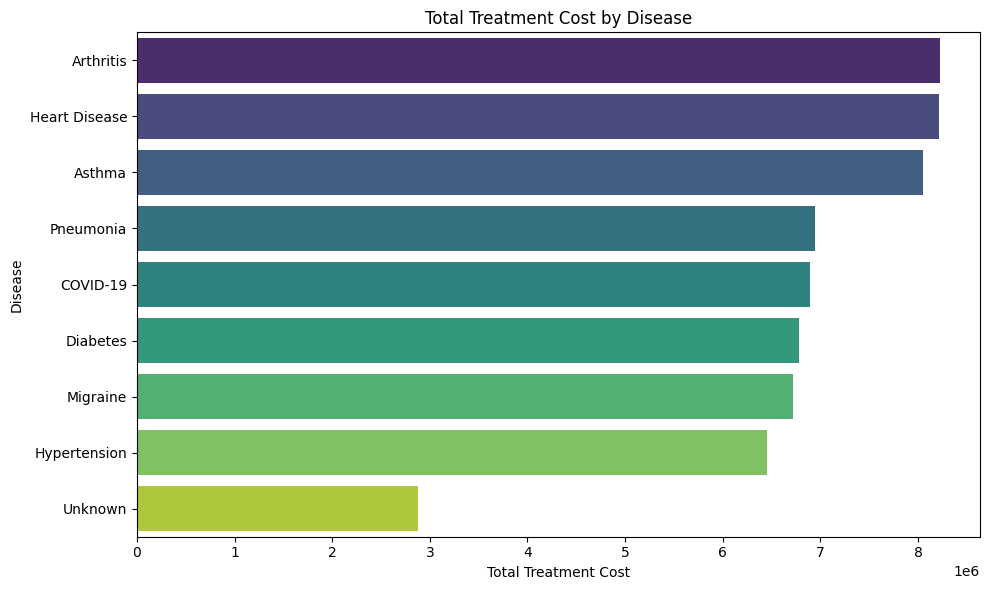


Which department generates the highest revenue?


Department
Neurology           1.194890e+07
Oncology            1.157003e+07
Cardiology          9.985076e+06
Pulmonology         9.276586e+06
Orthopedics         9.262420e+06
General Medicine    9.125761e+06
Name: Treatment_Cost, dtype: float64


/tmp/ipykernel_1544/2360586706.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


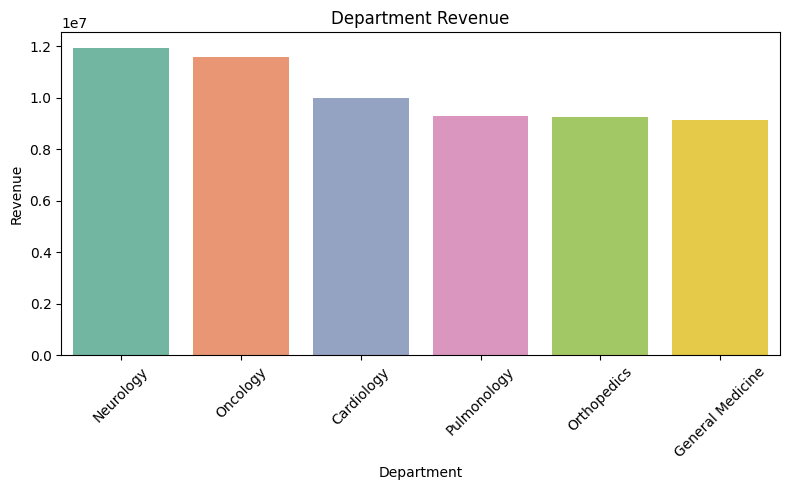


Average treatment cost by disease and insurance status


Insurance_Status             No            Yes
Disease                                       
Arthritis         131689.042274  133277.880683
Asthma            115100.500729  118784.233333
COVID-19          115756.287744  135175.429084
Diabetes           94427.961538  130946.454545
Heart Disease     117683.939394  135400.830789
Hypertension      139894.861137  123364.980351
Migraine          111437.421188  148626.411675
Pneumonia         119453.206897  102455.693684
Unknown           111346.101895  120884.052842


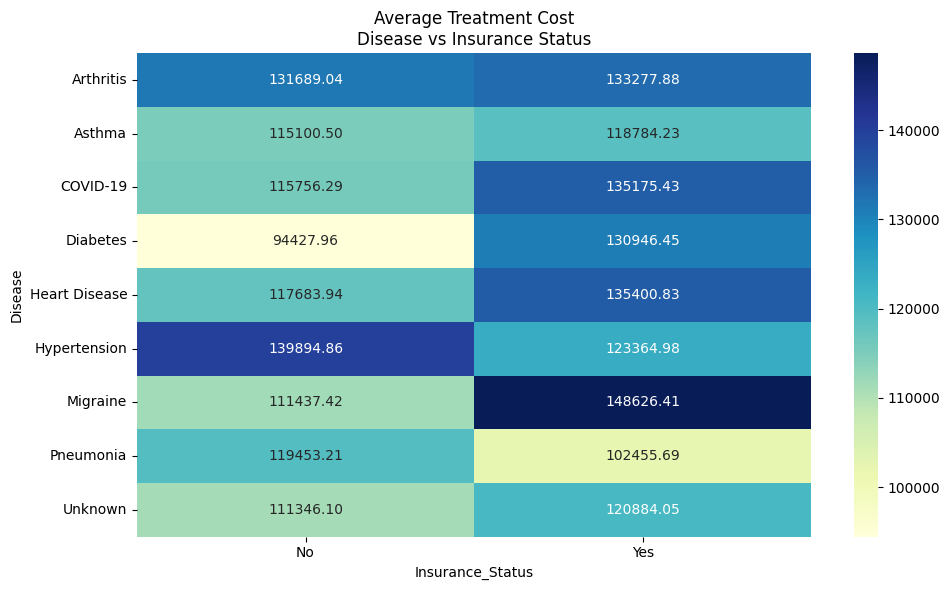


Percentage of treatment costs covered by insured patients


Insured Treatment Cost : 31721479.45
Uninsured Treatment Cost : 29447284.76
Percentage Covered : 51.86%


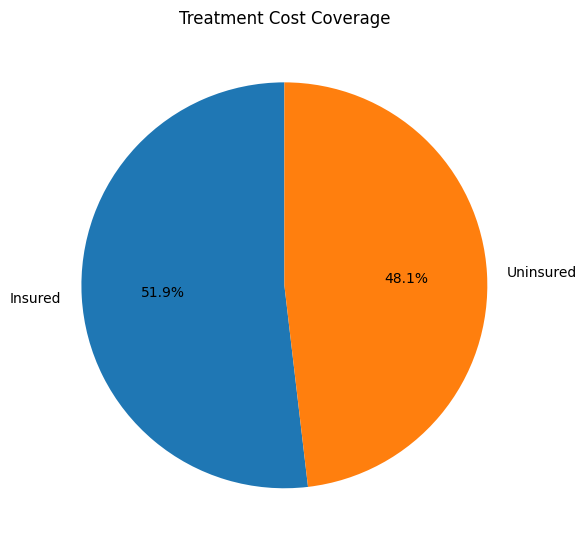


Which city has the highest average treatment cost?


City
Delhi        138407.746726
Bengaluru    128267.672241
Kolkata      127267.163173
Mumbai       122868.959543
Hyderabad    119578.829935
Patna        114072.898319
Pune         108612.091249
Name: Treatment_Cost, dtype: float64


/tmp/ipykernel_1544/2360586706.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


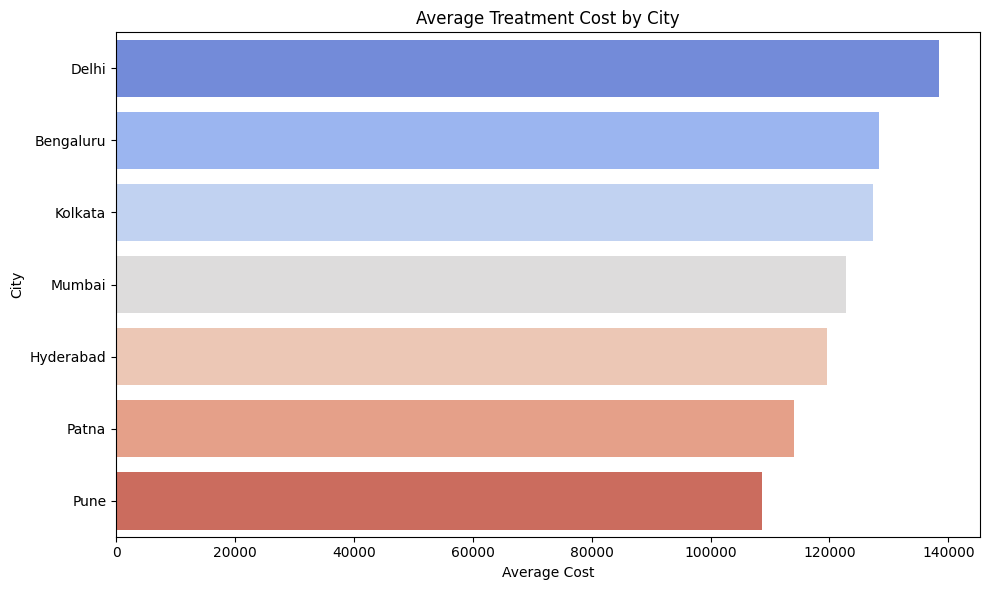

In [ ]:
# ============================================================
#                         BUSINESS ANALYSIS
# ============================================================

print("\n" + "="*70)
print("\nBUSINESS ANALYSIS\n")
print("="*70)

# Question 1

print("\nWhich disease contributes the highest total treatment cost?\n\n")

disease_cost = df.groupby("Disease")["Treatment_Cost"].sum().sort_values(ascending=False)
print(disease_cost)
plt.figure(figsize=(10,6))
sns.barplot(
    x=disease_cost.values,
    y=disease_cost.index,
    palette="viridis"
)
plt.title("Total Treatment Cost by Disease")
plt.xlabel("Total Treatment Cost")
plt.ylabel("Disease")
plt.tight_layout()
plt.savefig("visualizations/disease_cost.png")
plt.show()

# Question 2

print("\nWhich department generates the highest revenue?\n\n")
department_revenue = df.groupby("Department")["Treatment_Cost"].sum().sort_values(ascending=False)

print(department_revenue)
plt.figure(figsize=(8,5))
sns.barplot(
    x=department_revenue.index,
    y=department_revenue.values,
    palette="Set2"
)

plt.title("Department Revenue")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("visualizations/department_revenue.png")
plt.show()


# Question 3

print("\nAverage treatment cost by disease and insurance status\n\n")

avg_cost = df.pivot_table(
    values="Treatment_Cost",
    index="Disease",
    columns="Insurance_Status",
    aggfunc="mean"
)
print(avg_cost)
plt.figure(figsize=(10,6))
sns.heatmap(
    avg_cost,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)
plt.title("Average Treatment Cost\nDisease vs Insurance Status")
plt.tight_layout()
plt.savefig("visualizations/average_cost_heatmap.png")
plt.show()

# Question 4

print("\nPercentage of treatment costs covered by insured patients\n\n")

insured_cost = df[df["Insurance_Status"]=="Yes"]["Treatment_Cost"].sum()
uninsured_cost = df[df["Insurance_Status"]=="No"]["Treatment_Cost"].sum()
total_cost = insured_cost + uninsured_cost
insured_percentage = (insured_cost / total_cost) * 100
print(f"Insured Treatment Cost : {insured_cost:.2f}")
print(f"Uninsured Treatment Cost : {uninsured_cost:.2f}")
print(f"Percentage Covered : {insured_percentage:.2f}%")
plt.figure(figsize=(6,6))
plt.pie(
    [insured_cost, uninsured_cost],
    labels=["Insured","Uninsured"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Treatment Cost Coverage")
plt.tight_layout()
plt.savefig("visualizations/insurance_distribution.png")
plt.show()

# Question 5

print("\nWhich city has the highest average treatment cost?\n\n")

city_cost = df.groupby("City")["Treatment_Cost"].mean().sort_values(ascending=False)
print(city_cost)
plt.figure(figsize=(10,6))

sns.barplot(
    x=city_cost.values,
    y=city_cost.index,
    palette="coolwarm"
)

plt.title("Average Treatment Cost by City")
plt.xlabel("Average Cost")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("visualizations/city_average_cost.png")
plt.show()


PATIENT DEMOGRAPHICS ANALYSIS

Which age group contributes the highest healthcare expenditure?


age_group_cost



/tmp/ipykernel_1544/135451207.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_cost = df.groupby("Age_Group")["Treatment_Cost"].sum().sort_values(ascending=False)
/tmp/ipykernel_1544/135451207.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


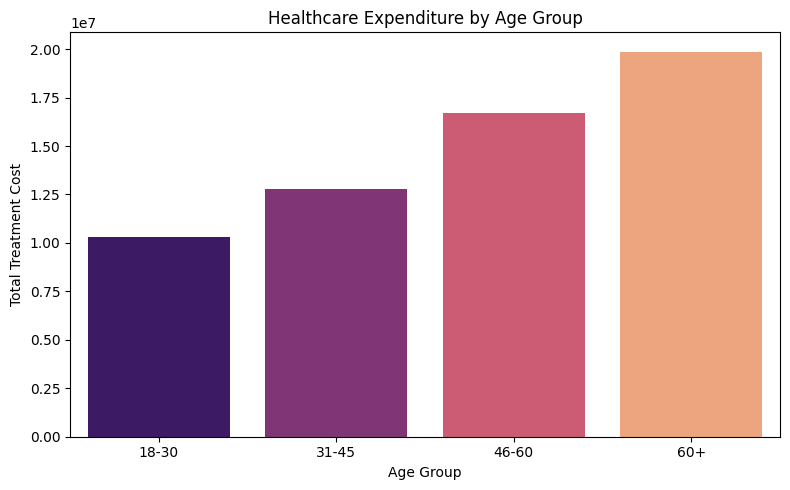


Most common diseases among different age groups


disease_age



/tmp/ipykernel_1544/135451207.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disease_age = df.groupby(


<Figure size 1200x600 with 0 Axes>

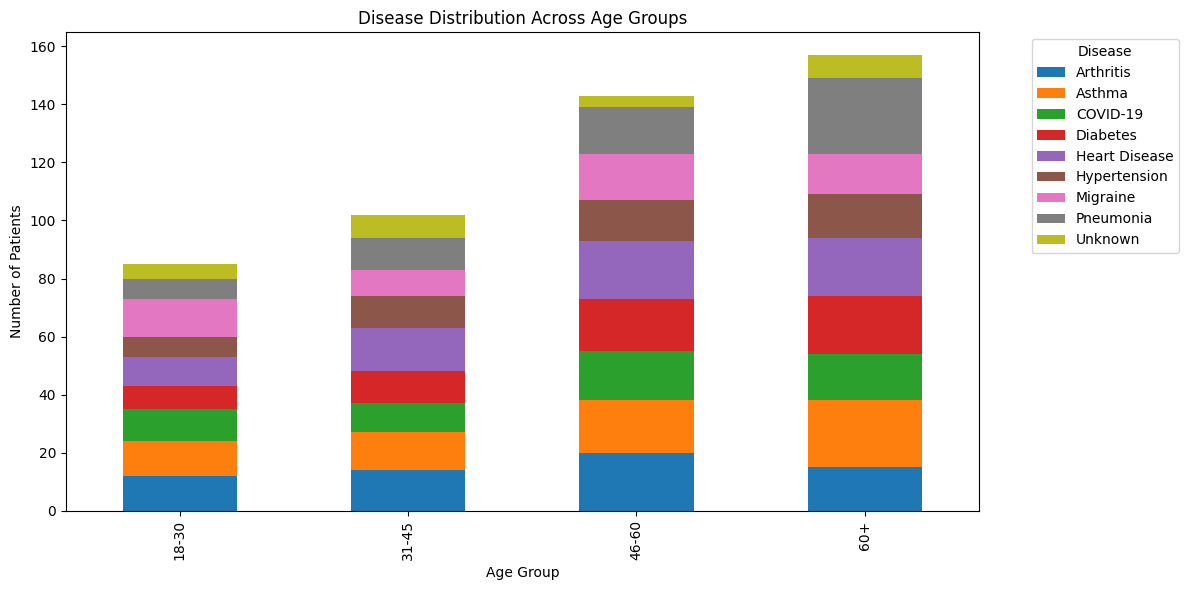


Treatment cost comparison between Male and Female

gender_cost



/tmp/ipykernel_1544/135451207.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


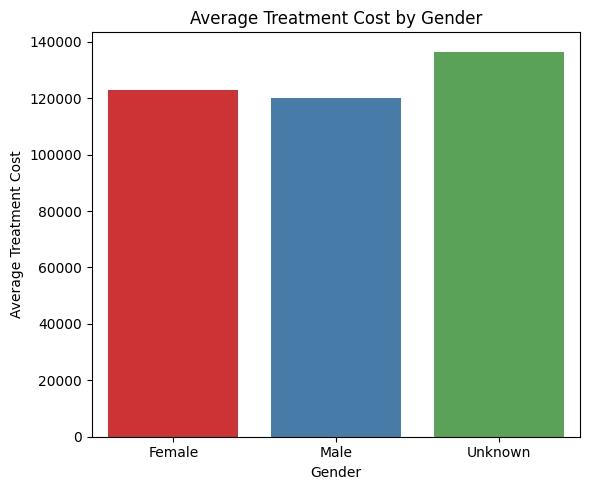


Blood Group with highest Critical Outcomes


blood_group



/tmp/ipykernel_1544/135451207.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


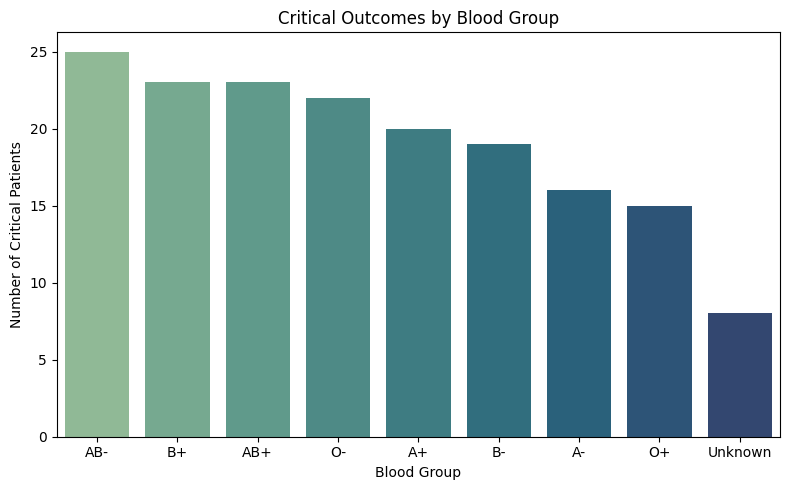

In [ ]:
# ============================================================
#                  PATIENT DEMOGRAPHICS ANALYSIS
# ============================================================

print("\n" + "="*70)
print("PATIENT DEMOGRAPHICS ANALYSIS")
print("="*70)

# Question 6

print("\nWhich age group contributes the highest healthcare expenditure?\n")

age_group_cost = df.groupby("Age_Group")["Treatment_Cost"].sum().sort_values(ascending=False)
print("\nage_group_cost\n")
plt.figure(figsize=(8,5))
sns.barplot(
    x=age_group_cost.index,
    y=age_group_cost.values,
    palette="magma"
)
plt.title("Healthcare Expenditure by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Treatment Cost")
plt.tight_layout()
plt.savefig("visualizations/age_group_expenditure.png")
plt.show()

# Question 7

print("\nMost common diseases among different age groups\n")

disease_age = df.groupby(
    ["Age_Group","Disease"]
).size().reset_index(name="Patient_Count")
print("\ndisease_age\n")
pivot = disease_age.pivot(
    index="Age_Group",
    columns="Disease",
    values="Patient_Count"
).fillna(0)
plt.figure(figsize=(12,6))
pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)
plt.title("Disease Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.legend(title="Disease",bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig("visualizations/disease_age_group.png")
plt.show()

# Question 8

print("\nTreatment cost comparison between Male and Female")

gender_cost = df.groupby("Gender")["Treatment_Cost"].mean()
print("\ngender_cost\n")
plt.figure(figsize=(6,5))
sns.barplot(
    x=gender_cost.index,
    y=gender_cost.values,
    palette="Set1"
)
plt.title("Average Treatment Cost by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Treatment Cost")
plt.tight_layout()
plt.savefig("visualizations/gender_cost.png")
plt.show()

# Question 9

print("\nBlood Group with highest Critical Outcomes\n")

critical = df[df["Outcome"]=="Critical"]
blood_group = critical["Blood_Group"].value_counts()
print("\nblood_group\n")
plt.figure(figsize=(8,5))
sns.barplot(
    x=blood_group.index,
    y=blood_group.values,
    palette="crest"
)
plt.title("Critical Outcomes by Blood Group")
plt.xlabel("Blood Group")
plt.ylabel("Number of Critical Patients")
plt.tight_layout()
plt.savefig("visualizations/blood_group_critical.png")
plt.show()
print("\n")